In [51]:
import json

import numpy as np

from qiskit.circuit import ClassicalRegister, ParameterVector, QuantumCircuit, QuantumRegister
from qiskit.result import marginal_counts
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator, SamplerV2 as Sampler

Example of file format `credentials.json`

```json
{
    "token": "your api key",
    "instance": "instance CRN",
    "channel": "ibm_cloud"
}
```

Warning: Do not share you api key with other people or upload it on a GitHub repository. Always remember to include the file name, or the folder name where the file is, in your `.gitignore` file. 

In [2]:
with open(file="../secrets/credentials.json", mode="rt") as f:
    credentials = json.load(f)

In [4]:
service = QiskitRuntimeService(**credentials)

qiskit_runtime_service._discover_account:WARNING:2026-04-26 16:00:04,146: Loading account with the given token. A saved account will not be used.


In [5]:
service.backends()

[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_kingston')>,
 <IBMBackend('ibm_marrakesh')>]

In [6]:
service.backends(dynamic_circuits=True)

[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_kingston')>,
 <IBMBackend('ibm_marrakesh')>]

Estimator

In [7]:
backend = service.backend(name="ibm_fez")

In [8]:
estimator = Estimator(mode=backend)

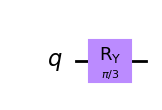

In [47]:
qc = QuantumCircuit(1)
qc.ry(theta=np.pi/3, qubit=0)
qc.draw(output="mpl", style="clifford")

In [13]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
tqc = pm.run(qc)

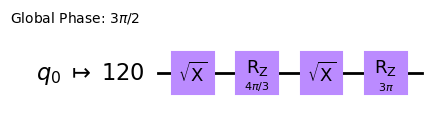

In [14]:
tqc.draw(output="mpl", style="clifford")

In [48]:
Z = SparsePauliOp(data="Z", coeffs=[1])

In [16]:
Z.to_matrix()

array([[ 1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]])

In [18]:
Z_isa = Z.apply_layout(tqc.layout)

In [19]:
Z_isa

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j])

In [20]:
pubs = [(tqc, Z_isa)]

In [21]:
estimator_job = estimator.run(pubs=pubs)

In [60]:
# estimator_job.job_id()

In [41]:
estimator_job.status()

'DONE'

In [ ]:
estimator_result = estimator_job.result()
# estimator_result = service.job(job_id="job_id")

In [49]:
sv = Statevector(qc)
print(sv.expectation_value(Z))

(0.5000000000000002+0j)


In [45]:
estimator_result[0].data.evs

array(0.51731186)

In [46]:
estimator_result[0].data.stds

array(0.01513124)

Sampler

In [27]:
backend = service.backend(name="ibm_kingston")

In [28]:
sampler = Sampler(mode=backend)

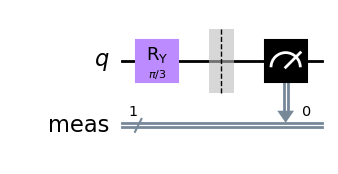

In [34]:
qc = QuantumCircuit(1)
qc.ry(theta=np.pi/3, qubit=0)
qc.measure_all()
qc.draw(output="mpl", style="clifford")

In [35]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
tqc = pm.run(qc)

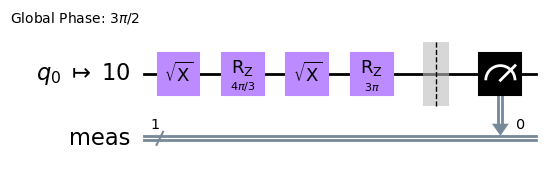

In [36]:
tqc.draw(output="mpl", style="clifford")

In [37]:
pubs = [(tqc)]

In [38]:
sampler_job = sampler.run(pubs=pubs, shots=4096)

In [59]:
# sampler_job.job_id()

In [50]:
sampler_job.status()

'RUNNING'

In [55]:
sampler_result = sampler_job.result()
# sampler_result = service.job(job_id="job_id")

In [57]:
sampler_result[0].data.meas.get_counts()

{'0': 3036, '1': 1060}

In [52]:
qc = QuantumCircuit(1)
qc.ry(theta=np.pi/3, qubit=0)
sv = Statevector(qc)

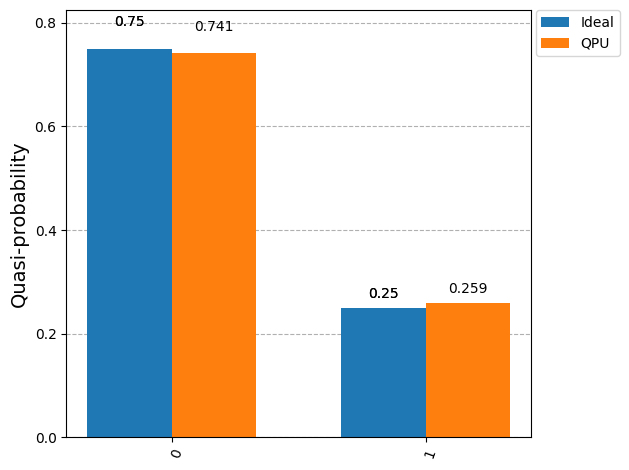

In [58]:
plot_histogram(data=[sv.probabilities_dict(), sampler_result[0].data.meas.get_counts()], legend=["Ideal", "QPU"])